In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"D:\dattu\Data Science\05_MachineLearning\ML_Projects\03_Customer_Segmentation\Data\Customer-Data - 2.csv")

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [7]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].describe()

,CREDIT_LIMIT,MINIMUM_PAYMENTS
count,8949.000000,8637.000000
mean,4494.449450,864.206542
std,3638.815725,2372.446607
min,50.000000,0.019163
25%,1600.000000,169.123707
50%,3000.000000,312.343947
75%,6500.000000,825.485459
max,30000.000000,76406.207520


In [10]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(
    df["CREDIT_LIMIT"].median()
)

df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median()
)

In [11]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [12]:
list(df.columns)

['CUST_ID',
 'BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

In [13]:
numerical_df = df.drop("CUST_ID", axis=1)

In [14]:
numerical_df.corr()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531296,0.322802,0.397920,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095931,0.065008,0.131181,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356977,0.603264,0.095789,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319735,0.567292,0.050256,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256515,0.384084,0.134019,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303997,0.453238,0.140747,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119833,0.103464,0.006154,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295059,0.243537,-0.027311,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060794,0.085551,0.032055,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132608,0.183192,0.100616,-0.249773,-0.133372


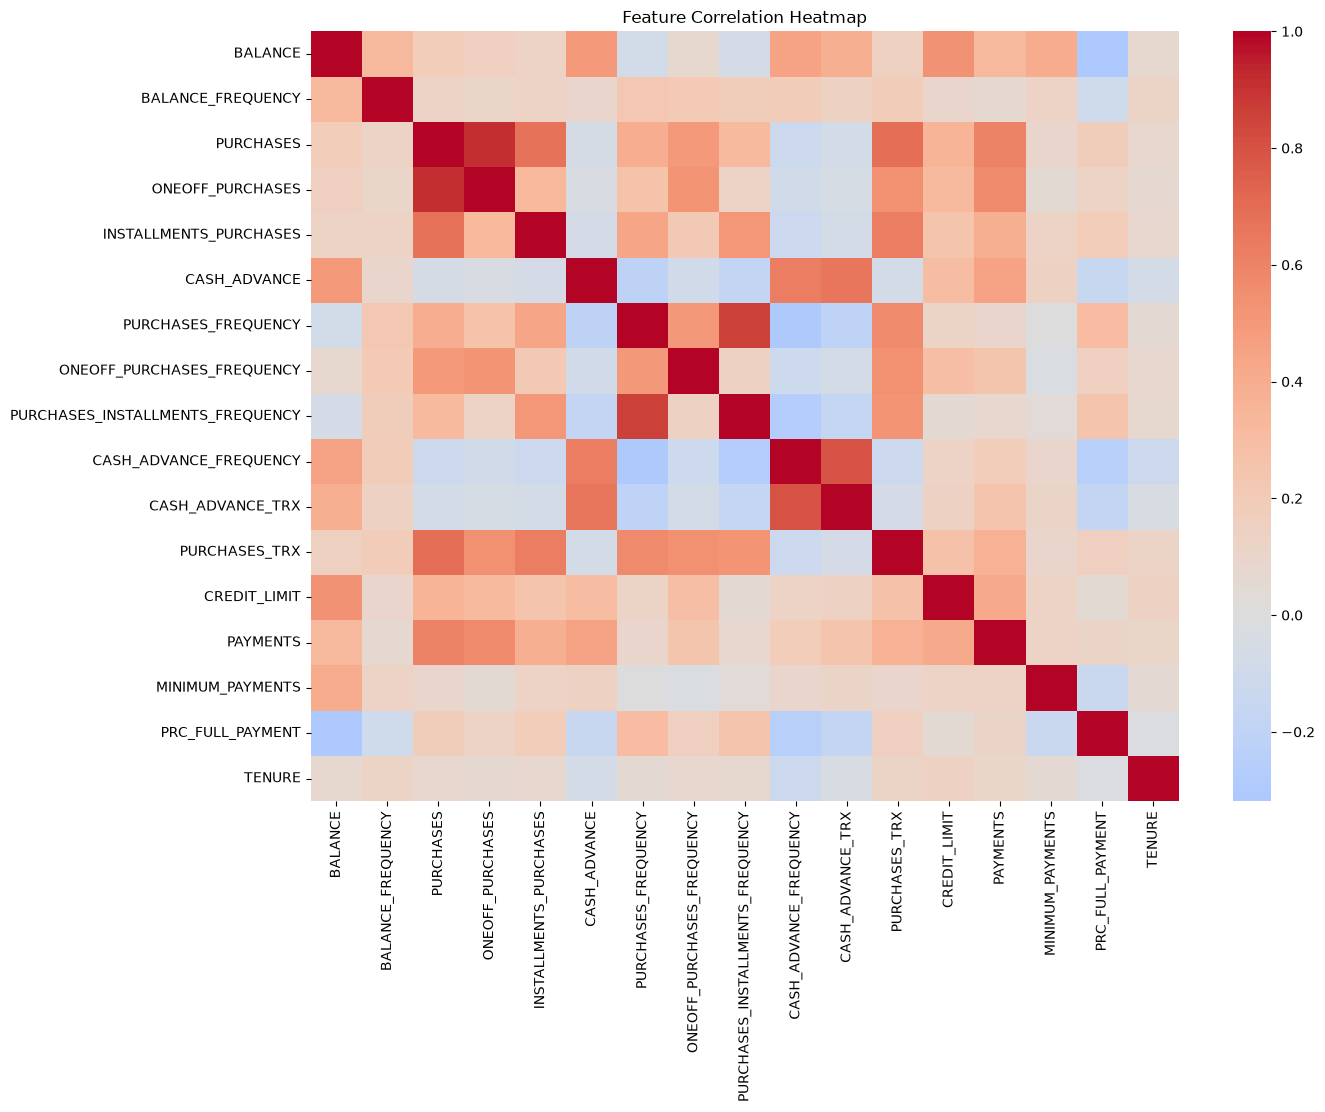

<Figure size 640x480 with 0 Axes>

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(numerical_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_MachineLearning\ML_Projects\03_Customer_Segmentation\outputs\Feature_Correlation_Heatmap.png", dpi=300, bbox_inches='tight')

In [16]:
corr_matrix = numerical_df.corr()

corr_matrix.round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.00,0.32,0.18,0.16,0.13,0.50,-0.08,0.07,-0.06,0.45,0.39,0.15,0.53,0.32,0.40,-0.32,0.07
BALANCE_FREQUENCY,0.32,1.00,0.13,0.10,0.12,0.10,0.23,0.20,0.18,0.19,0.14,0.19,0.10,0.07,0.13,-0.10,0.12
PURCHASES,0.18,0.13,1.00,0.92,0.68,-0.05,0.39,0.50,0.32,-0.12,-0.07,0.69,0.36,0.60,0.10,0.18,0.09
ONEOFF_PURCHASES,0.16,0.10,0.92,1.00,0.33,-0.03,0.26,0.52,0.13,-0.08,-0.05,0.55,0.32,0.57,0.05,0.13,0.06
INSTALLMENTS_PURCHASES,0.13,0.12,0.68,0.33,1.00,-0.06,0.44,0.21,0.51,-0.13,-0.07,0.63,0.26,0.38,0.13,0.18,0.09
CASH_ADVANCE,0.50,0.10,-0.05,-0.03,-0.06,1.00,-0.22,-0.09,-0.18,0.63,0.66,-0.08,0.30,0.45,0.14,-0.15,-0.07
PURCHASES_FREQUENCY,-0.08,0.23,0.39,0.26,0.44,-0.22,1.00,0.50,0.86,-0.31,-0.20,0.57,0.12,0.10,0.01,0.31,0.06
ONEOFF_PURCHASES_FREQUENCY,0.07,0.20,0.50,0.52,0.21,-0.09,0.50,1.00,0.14,-0.11,-0.07,0.54,0.30,0.24,-0.03,0.16,0.08
PURCHASES_INSTALLMENTS_FREQUENCY,-0.06,0.18,0.32,0.13,0.51,-0.18,0.86,0.14,1.00,-0.26,-0.17,0.53,0.06,0.09,0.03,0.25,0.07
CASH_ADVANCE_FREQUENCY,0.45,0.19,-0.12,-0.08,-0.13,0.63,-0.31,-0.11,-0.26,1.00,0.80,-0.13,0.13,0.18,0.10,-0.25,-0.13


In [17]:
corr_matrix = numerical_df.corr()

strong_corr = corr_matrix[
    (corr_matrix > 0.7) | (corr_matrix < -0.7)
]

strong_corr

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALANCE_FREQUENCY,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PURCHASES,NaN,NaN,1.000000,0.916845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ONEOFF_PURCHASES,NaN,NaN,0.916845,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INSTALLMENTS_PURCHASES,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASH_ADVANCE,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PURCHASES_FREQUENCY,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.862934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ONEOFF_PURCHASES_FREQUENCY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PURCHASES_INSTALLMENTS_FREQUENCY,NaN,NaN,NaN,NaN,NaN,NaN,0.862934,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASH_ADVANCE_FREQUENCY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.799561,NaN,NaN,NaN,NaN,NaN,NaN


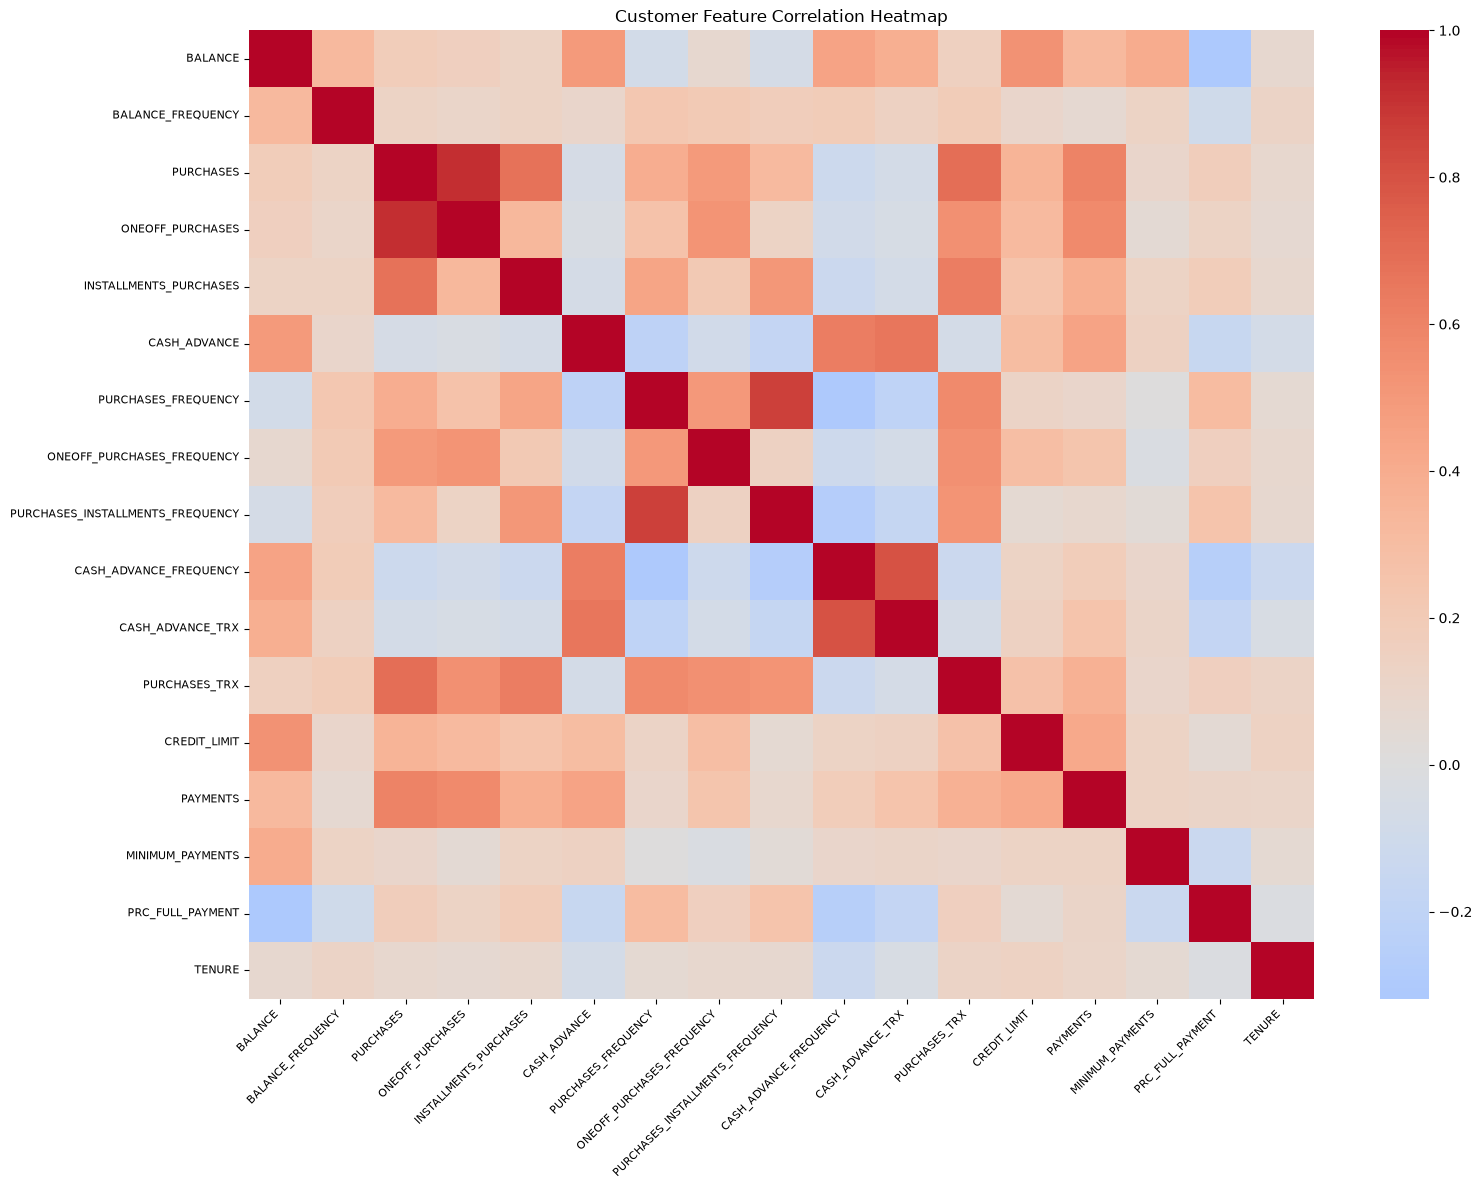

In [18]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    numerical_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.title("Customer Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
numerical_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


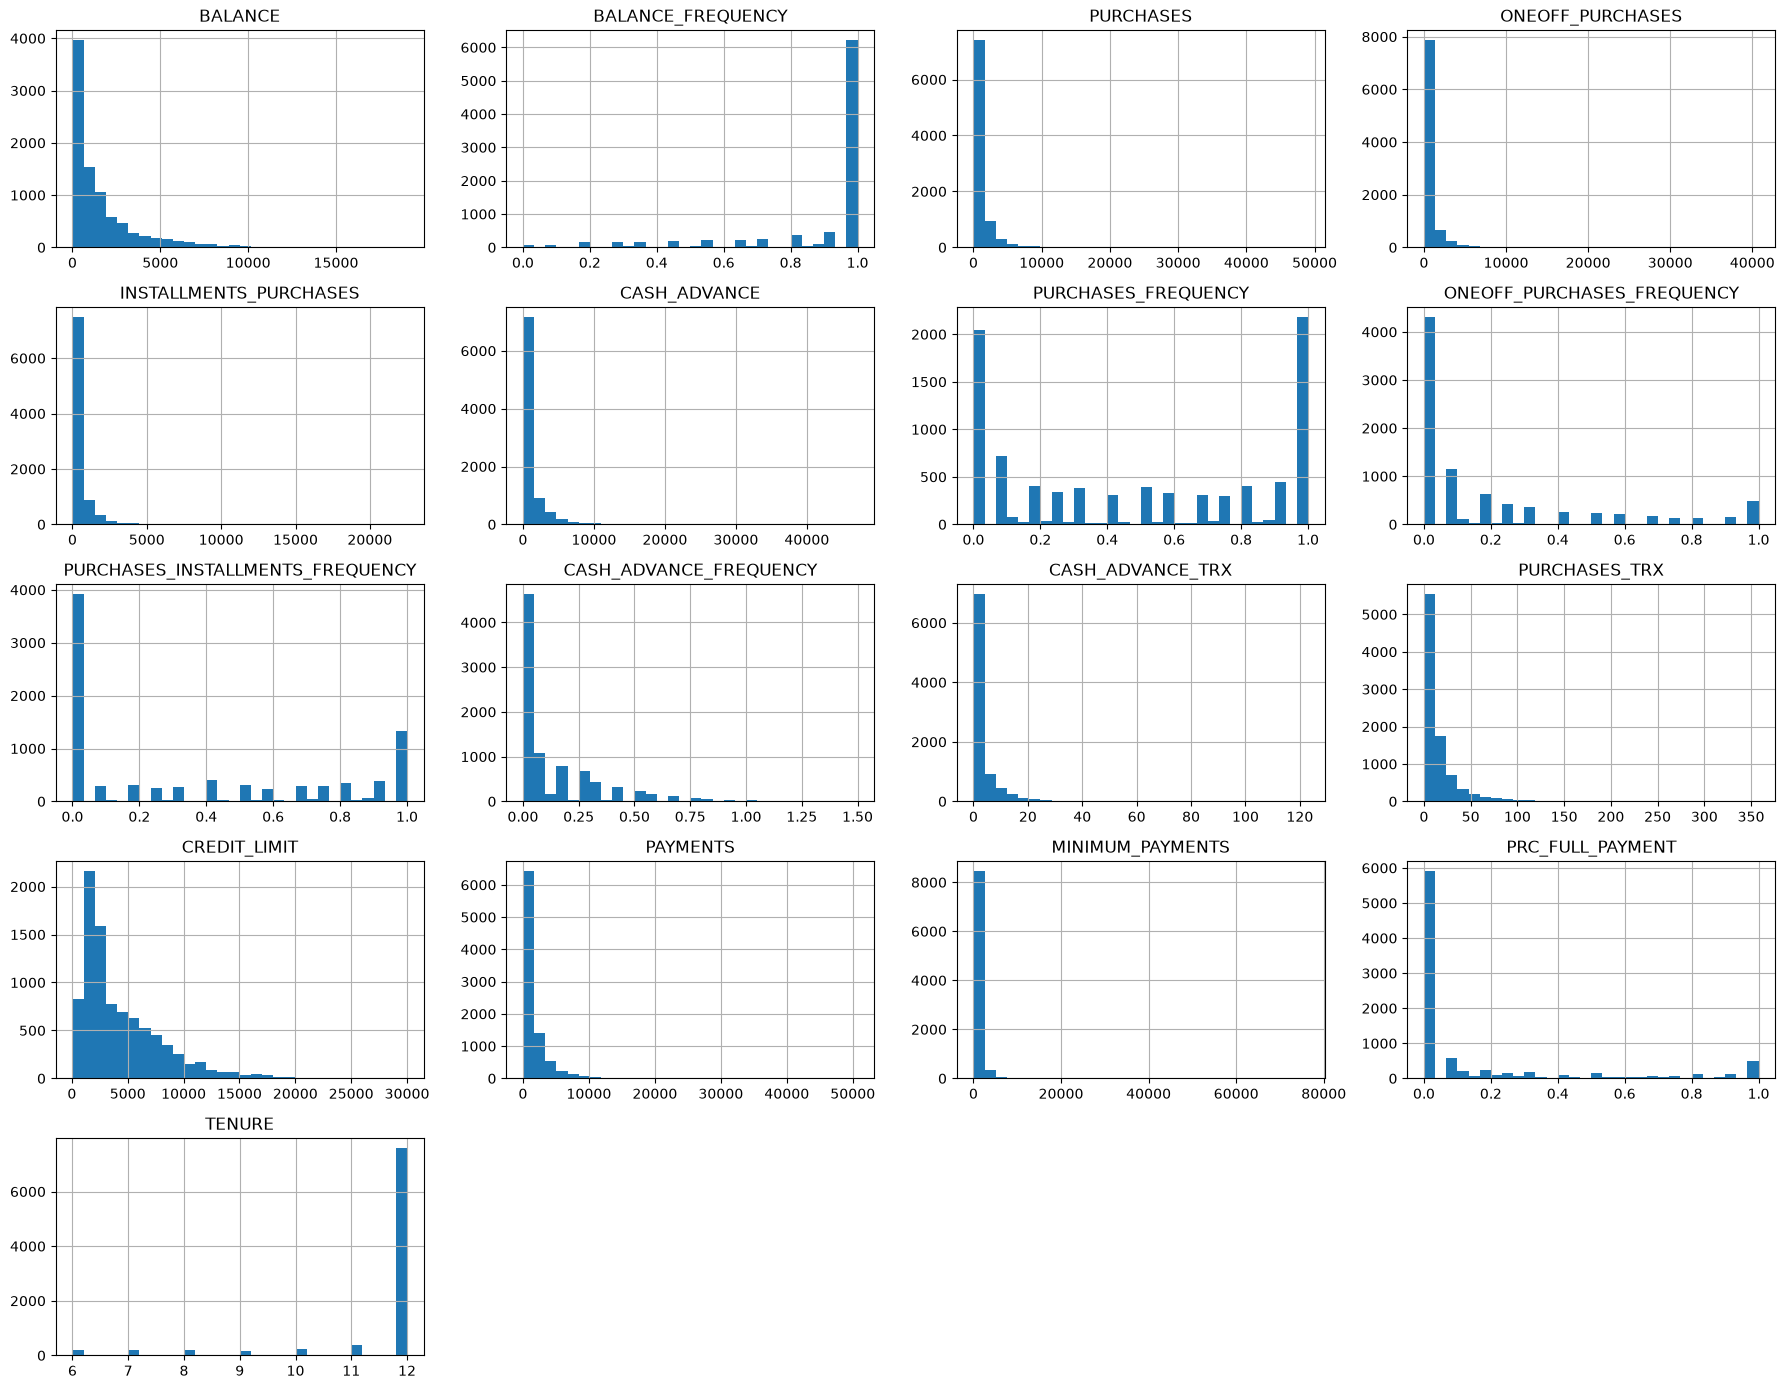

<Figure size 640x480 with 0 Axes>

In [20]:
numerical_df.hist(figsize=(18, 14), bins=30)

plt.tight_layout()
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_MachineLearning\ML_Projects\03_Customer_Segmentation\outputs\Customer_Feature_Distribution_Histogram.jpg", dpi=300, bbox_inches='tight')

In [21]:
numerical_df.skew().sort_values(ascending=False)

MINIMUM_PAYMENTS                    13.852446
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522636
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

In [22]:
skewed_cols = [
    "MINIMUM_PAYMENTS",
    "ONEOFF_PURCHASES",
    "PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "PAYMENTS",
    "CASH_ADVANCE_TRX",
    "CASH_ADVANCE",
    "PURCHASES_TRX",
    "BALANCE"
]

X_log = numerical_df.copy()

X_log[skewed_cols] = np.log1p(X_log[skewed_cols])

In [23]:
X_log.skew().sort_values(ascending=False)

PRC_FULL_PAYMENT                    1.942820
CASH_ADVANCE_FREQUENCY              1.828686
ONEOFF_PURCHASES_FREQUENCY          1.535613
CREDIT_LIMIT                        1.522636
CASH_ADVANCE_TRX                    0.940131
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
MINIMUM_PAYMENTS                    0.269703
CASH_ADVANCE                        0.262594
ONEOFF_PURCHASES                    0.185854
PURCHASES_FREQUENCY                 0.060164
PURCHASES_TRX                       0.032697
INSTALLMENTS_PURCHASES             -0.024981
PURCHASES                          -0.764492
BALANCE                            -0.861021
PAYMENTS                           -1.778312
BALANCE_FREQUENCY                  -2.023266
TENURE                             -2.943017
dtype: float64

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

In [25]:
X_scaled.shape

(8950, 17)

c:\Users\NATRAJ\miniconda3\envs\datascience\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\NATRAJ\miniconda3\envs\datascience\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\NATRAJ\miniconda3\envs\datascience\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\NATRAJ\miniconda3\envs\datascience\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, *

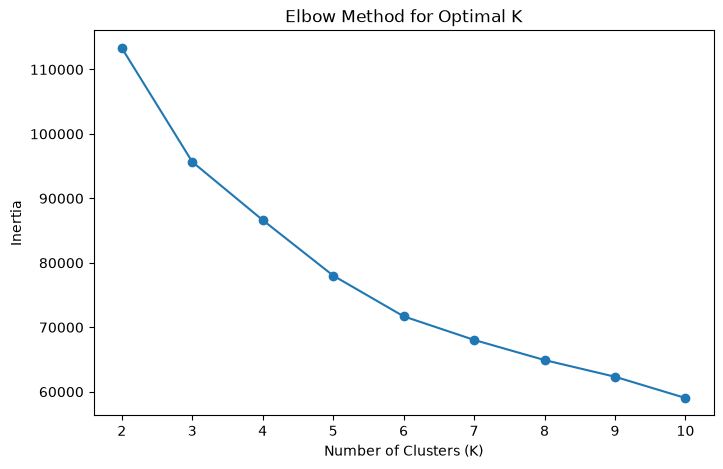

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

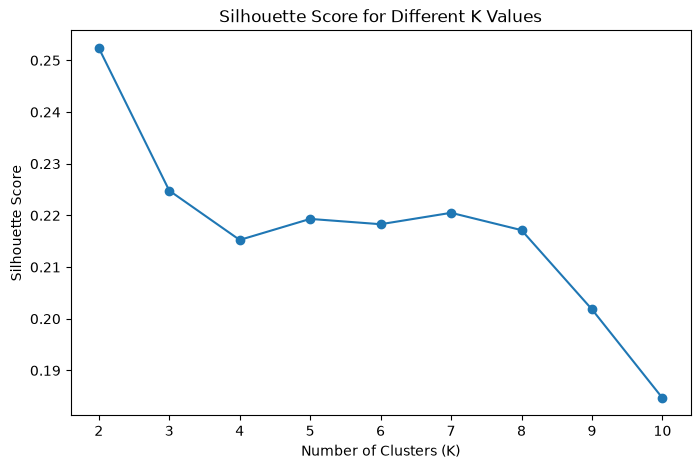

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [28]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_4 = kmeans_4.fit_predict(X_scaled)

df["Cluster_4"] = labels_4

In [29]:
df["Cluster_4"].value_counts().sort_index()

Cluster_4
0    2522
1    2723
2    2078
3    1627
Name: count, dtype: int64

In [30]:
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels_5 = kmeans_5.fit_predict(X_scaled)

df["Cluster_5"] = labels_5

In [31]:
df["Cluster_5"].value_counts().sort_index()

Cluster_5
0    1500
1    2336
2    1887
3    1826
4    1401
Name: count, dtype: int64

In [32]:
cluster_profile_4 = df.groupby("Cluster_4")[numerical_df.columns].mean()

cluster_profile_4.round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster_4,,,,,,,,,,,,,,,,,
0,2290.26,0.98,2635.64,1764.42,871.28,895.33,0.84,0.56,0.56,0.12,2.98,36.13,6431.05,2976.48,1115.88,0.17,11.80
1,2465.32,0.94,100.06,77.17,22.93,2239.44,0.07,0.04,0.03,0.31,7.44,1.19,4359.94,1825.47,1126.42,0.03,11.39
2,501.51,0.92,698.32,67.97,631.33,105.87,0.82,0.04,0.77,0.02,0.35,14.96,2982.64,862.20,636.25,0.29,11.47
3,289.39,0.56,373.71,307.96,65.97,113.64,0.24,0.13,0.11,0.02,0.36,3.82,3647.61,763.72,220.22,0.16,11.35


In [33]:
cluster_profile_5 = df.groupby("Cluster_5")[numerical_df.columns].mean()

cluster_profile_5.round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster_5,,,,,,,,,,,,,,,,,
0,244.70,0.53,339.49,271.06,68.66,119.01,0.23,0.11,0.11,0.02,0.38,3.51,3575.09,743.25,199.89,0.15,11.31
1,2275.51,0.93,27.60,25.14,2.51,2003.03,0.02,0.02,0.00,0.28,6.53,0.33,4088.47,1657.39,1067.04,0.03,11.42
2,468.56,0.92,662.57,46.57,616.92,33.98,0.81,0.03,0.76,0.01,0.12,14.63,2966.71,818.75,666.78,0.30,11.51
3,1547.47,0.97,2886.08,1997.23,888.93,56.04,0.84,0.62,0.53,0.01,0.17,37.24,6387.43,2729.86,717.10,0.25,11.87
4,3290.18,0.97,1345.28,786.70,558.81,2667.28,0.67,0.30,0.48,0.35,9.07,21.41,5745.11,2851.82,1571.60,0.04,11.46


In [34]:
df["Cluster"] = labels_5

In [35]:
df.drop(["Cluster_4", "Cluster_5"], axis=1, inplace=True)

In [36]:
cluster_profile_5.T.round(2)

Cluster_5,0,1,2,3,4
BALANCE,244.70,2275.51,468.56,1547.47,3290.18
BALANCE_FREQUENCY,0.53,0.93,0.92,0.97,0.97
PURCHASES,339.49,27.60,662.57,2886.08,1345.28
ONEOFF_PURCHASES,271.06,25.14,46.57,1997.23,786.70
INSTALLMENTS_PURCHASES,68.66,2.51,616.92,888.93,558.81
CASH_ADVANCE,119.01,2003.03,33.98,56.04,2667.28
PURCHASES_FREQUENCY,0.23,0.02,0.81,0.84,0.67
ONEOFF_PURCHASES_FREQUENCY,0.11,0.02,0.03,0.62,0.30
PURCHASES_INSTALLMENTS_FREQUENCY,0.11,0.00,0.76,0.53,0.48
CASH_ADVANCE_FREQUENCY,0.02,0.28,0.01,0.01,0.35


In [37]:
profile_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PURCHASES_TRX",
    "CASH_ADVANCE_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "PRC_FULL_PAYMENT"
]

cluster_profile_5[profile_features].T.round(2)

Cluster_5,0,1,2,3,4
BALANCE,244.70,2275.51,468.56,1547.47,3290.18
PURCHASES,339.49,27.60,662.57,2886.08,1345.28
CASH_ADVANCE,119.01,2003.03,33.98,56.04,2667.28
PURCHASES_FREQUENCY,0.23,0.02,0.81,0.84,0.67
CASH_ADVANCE_FREQUENCY,0.02,0.28,0.01,0.01,0.35
PURCHASES_TRX,3.51,0.33,14.63,37.24,21.41
CASH_ADVANCE_TRX,0.38,6.53,0.12,0.17,9.07
CREDIT_LIMIT,3575.09,4088.47,2966.71,6387.43,5745.11
PAYMENTS,743.25,1657.39,818.75,2729.86,2851.82
PRC_FULL_PAYMENT,0.15,0.03,0.30,0.25,0.04


In [38]:
overall_mean = numerical_df.mean()

cluster_comparison = cluster_profile_5[profile_features] / overall_mean[profile_features]

cluster_comparison.T.round(2)

Cluster_5,0,1,2,3,4
BALANCE,0.16,1.45,0.30,0.99,2.10
PURCHASES,0.34,0.03,0.66,2.88,1.34
CASH_ADVANCE,0.12,2.05,0.03,0.06,2.72
PURCHASES_FREQUENCY,0.47,0.05,1.65,1.70,1.37
CASH_ADVANCE_FREQUENCY,0.17,2.07,0.06,0.09,2.56
PURCHASES_TRX,0.24,0.02,0.99,2.53,1.46
CASH_ADVANCE_TRX,0.12,2.01,0.04,0.05,2.79
CREDIT_LIMIT,0.80,0.91,0.66,1.42,1.28
PAYMENTS,0.43,0.96,0.47,1.58,1.65
PRC_FULL_PAYMENT,0.99,0.20,1.98,1.60,0.24


In [39]:
cluster_profile_5[profile_features].T.round(2)

Cluster_5,0,1,2,3,4
BALANCE,244.70,2275.51,468.56,1547.47,3290.18
PURCHASES,339.49,27.60,662.57,2886.08,1345.28
CASH_ADVANCE,119.01,2003.03,33.98,56.04,2667.28
PURCHASES_FREQUENCY,0.23,0.02,0.81,0.84,0.67
CASH_ADVANCE_FREQUENCY,0.02,0.28,0.01,0.01,0.35
PURCHASES_TRX,3.51,0.33,14.63,37.24,21.41
CASH_ADVANCE_TRX,0.38,6.53,0.12,0.17,9.07
CREDIT_LIMIT,3575.09,4088.47,2966.71,6387.43,5745.11
PAYMENTS,743.25,1657.39,818.75,2729.86,2851.82
PRC_FULL_PAYMENT,0.15,0.03,0.30,0.25,0.04


In [40]:
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels_5 = kmeans_5.fit_predict(X_scaled)

In [41]:
df["Cluster"] = labels_5

In [44]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1500
1    2336
2    1887
3    1826
4    1401
Name: count, dtype: int64

In [45]:
cluster_profile = df.groupby("Cluster")[numerical_df.columns].mean()

cluster_profile.T.round(2)

Cluster,0,1,2,3,4
BALANCE,244.70,2275.51,468.56,1547.47,3290.18
BALANCE_FREQUENCY,0.53,0.93,0.92,0.97,0.97
PURCHASES,339.49,27.60,662.57,2886.08,1345.28
ONEOFF_PURCHASES,271.06,25.14,46.57,1997.23,786.70
INSTALLMENTS_PURCHASES,68.66,2.51,616.92,888.93,558.81
CASH_ADVANCE,119.01,2003.03,33.98,56.04,2667.28
PURCHASES_FREQUENCY,0.23,0.02,0.81,0.84,0.67
ONEOFF_PURCHASES_FREQUENCY,0.11,0.02,0.03,0.62,0.30
PURCHASES_INSTALLMENTS_FREQUENCY,0.11,0.00,0.76,0.53,0.48
CASH_ADVANCE_FREQUENCY,0.02,0.28,0.01,0.01,0.35


In [46]:
cluster_names = {
    0: "Low Activity",
    1: "Cash Advance Focused",
    2: "Installment Focused",
    3: "High Value Purchasers",
    4: "Heavy Overall Users"
}

df["Segment"] = df["Cluster"].map(cluster_names)

In [47]:
df[["CUST_ID", "Cluster", "Segment"]].head(10)

,CUST_ID,Cluster,Segment
0,C10001,0,Low Activity
1,C10002,1,Cash Advance Focused
2,C10003,3,High Value Purchasers
3,C10004,0,Low Activity
4,C10005,0,Low Activity
5,C10006,2,Installment Focused
6,C10007,3,High Value Purchasers
7,C10008,2,Installment Focused
8,C10009,3,High Value Purchasers
9,C10010,0,Low Activity


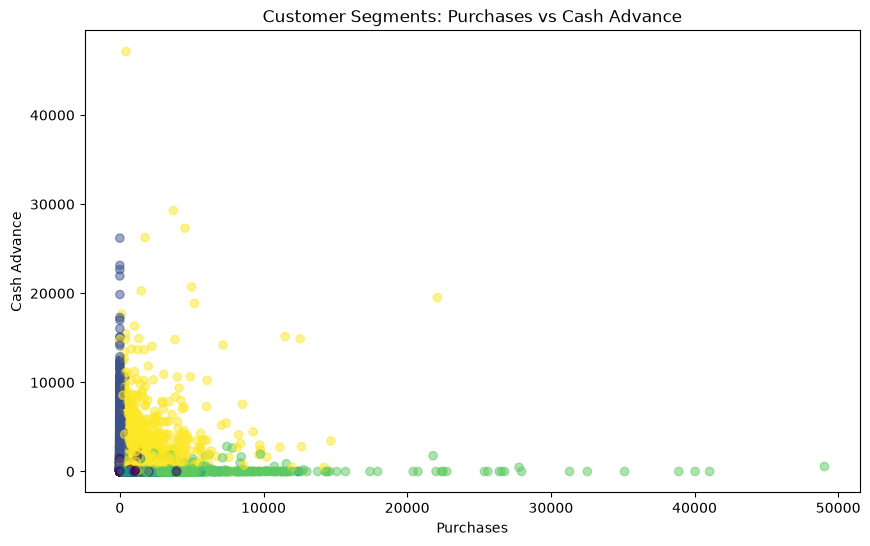

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["PURCHASES"],
    df["CASH_ADVANCE"],
    c=df["Cluster"],
    alpha=0.5
)

plt.xlabel("Purchases")
plt.ylabel("Cash Advance")
plt.title("Customer Segments: Purchases vs Cash Advance")

plt.show()

In [49]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(X_scaled, df["Cluster"])

print("Final Silhouette Score:", round(final_silhouette, 3))

Final Silhouette Score: 0.219
